# 02 — Body pose: cosa c'è e quanto se ne può usare

Il body pose arricchisce il tracking con **29 giunti 3D per giocatore**, a 25 fps,
ognuno con un errore dichiarato in centimetri.

Interessa perché è il dato più vicino all'**intenzione** che SkillCorner
fornisca. Il tracking dice dov'è un giocatore; il pose dice da che parte è
girato, e un difensore che ha già ruotato le spalle sta preparando un movimento
diverso da uno ancora frontale.

La domanda di questo notebook è però preliminare: **quanto di questo dato è
davvero utilizzabile?**

> Perché la domanda vale la pena: su 13 paper difensivi in `docs/`, "body pose"
> compare **zero volte** e "body orientation" **due**, entrambe come cosa che gli
> autori dichiarano di *non* aver usato. Vedi
> [`notes/letteratura/`](../notes/letteratura/README.md).

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib import pose, data

MATCH = 1925299
pd.set_option("display.width", 130)

## Dove vivono questi dati

Due partite su venti. I file interi non stanno nel repo dei dati — 3,3 GB di JSON
ciascuno, ~600 MB compressi — ma su Hugging Face. Nel repo c'è solo un campione,
per far girare i tutorial senza scaricare.

In [2]:
for mid, nome in pose.PARTITE.items():
    print(f"{mid}  {nome}   archivio locale: {pose.disponibile(mid)}")

print()
print("campione committato:", pose.CAMPIONE.name,
      f"({pose.CAMPIONE.stat().st_size/1e6:.1f} MB)")

1925299  Brisbane Roar v Perth Glory (2024-12-21)   archivio locale: True
1996435  Sydney FC v Adelaide United (2025-02-01)   archivio locale: False

campione committato: sample_1925299_phase406.jsonl.gz (1.9 MB)


Il campione **non è una partita in miniatura**: è una ripartenza di 12,3 secondi,
un tempo solo, senza sostituzioni e senza i tratti in cui il pose manca del tutto.
Codice sviluppato solo su quello si rompe sulla partita vera.

`pose.scarica(MATCH)` prende l'archivio e ne verifica lo sha256 contro il
manifest.

In [3]:
frame = next(f for f in pose.iter_match(MATCH, limit=40000)
             if f["frame"] >= 37500 and f["player_data"])

print("chiavi del frame:", list(frame))
print("giocatori nel frame:", len(frame["player_data"]))
print()

p = next(x for x in frame["player_data"] if x.get("joints"))
print("record giocatore:", {k: v for k, v in p.items() if k != "joints"})
print("giunti:", len(p["joints"]))
print()
for nome in ["neck", "lShoulder", "rShoulder", "lBigToe"]:
    g = p["joints"][nome]
    print(f"  {nome:12s} xyz={g['xyz']}   errore p90 = {g['p90_mae_cm']} cm")

chiavi del frame: ['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data']
giocatori nel frame: 32

record giocatore: {'player_id': 560985, 'x': -50.1, 'y': 2.38, 'is_detected': True}
giunti: 29

  neck         xyz=[-50.061, 2.418, 1.443]   errore p90 = 12.16 cm
  lShoulder    xyz=[-50.212, 2.513, 1.406]   errore p90 = 10.63 cm
  rShoulder    xyz=[-49.913, 2.319, 1.415]   errore p90 = 9.3 cm
  lBigToe      xyz=[-50.356, 2.557, 0.191]   errore p90 = 20.39 cm


## Il trabocchetto del denominatore

Prima cosa da non sbagliare, ed è la stessa trappola documentata in
[`notes/dati/`](../notes/dati/README.md): **i due file non contano le stesse
cose.**

In [4]:
n_player_frame = n_vuoti = 0
frame_tracking = []
for fr in data.iter_tracking(MATCH):
    frame_tracking.append(fr["frame"])
    n_player_frame += len(fr["player_data"])
    if not fr["player_data"]:
        n_vuoti += 1

print(f"TRACKING (10 fps): {len(frame_tracking):,} frame, "
      f"range {min(frame_tracking)}-{max(frame_tracking)}")
print(f"  frame vuoti:  {n_vuoti:,} ({100*n_vuoti/len(frame_tracking):.0f}%)")
print(f"  player-frame: {n_player_frame:,}   (22 giocatori, oppure zero)")

TRACKING (10 fps): 61,301 frame, range 0-61300
  frame vuoti:  13,359 (22%)
  player-frame: 1,054,724   (22 giocatori, oppure zero)


In [5]:
# Una passata sola sulla partita di pose, poi cache su disco: ~43 s di CPU.
# La funzione aggrega mentre scorre invece di accumulare 3,4 milioni di righe:
# una prima versione le accumulava, arrivava a 900 MB e non finiva.
cop = pose.copertura_partita(MATCH)

tot = cop["player_frame_totali"]
dentro = cop["player_frame_in_campo"]
con_pose = cop["con_pose"]

print(f"POSE (25 fps): {cop['frame']:,} frame")
print(f"  player-frame nel file:       {tot:,}")
print(f"  con il giocatore in campo:   {dentro:,}  ({100*dentro/tot:.0f}%)")
print()
print(f"ultimo frame pose / 2.5 = {cop['frame']/2.5:,.0f}"
      f"   ultimo frame tracking = {max(frame_tracking):,}")

POSE (25 fps): 153,252 frame
  player-frame nel file:       4,902,560
  con il giocatore in campo:   3,370,402  (69%)

ultimo frame pose / 2.5 = 61,301   ultimo frame tracking = 61,300


Due differenze, entrambe sul denominatore:

- il pose elenca **32 giocatori per frame** — la rosa intera, anche chi in quel
  momento è in panchina — mentre il tracking ne ha 22 o zero;
- il pose **non ha frame vuoti**: copre anche il gioco fermo, che nel tracking è
  il 22% dei frame.

La conversione invece torna esatta: `pose_frame = 2.5 × tracking_frame`.

Quindi la copertura va calcolata sui **giocatori effettivamente in campo**,
ricavati dai minuti giocati in `match.json`.

In [6]:
print(f"COPERTURA POSE (denominatore giusto): {100*con_pose/dentro:.1f}%")
print(f"copertura sul denominatore ingenuo:   {100*con_pose/tot:.1f}%")

COPERTURA POSE (denominatore giusto): 45.7%
copertura sul denominatore ingenuo:   31.4%


**45,7% contro 31,4%**, e la differenza è solo il denominatore. Il README
ufficiale del dataset cita "circa un terzo", cioè il numero ingenuo.

Resta comunque un dato per metà assente. E come nel tracking, l'assenza non è
distribuita a caso.

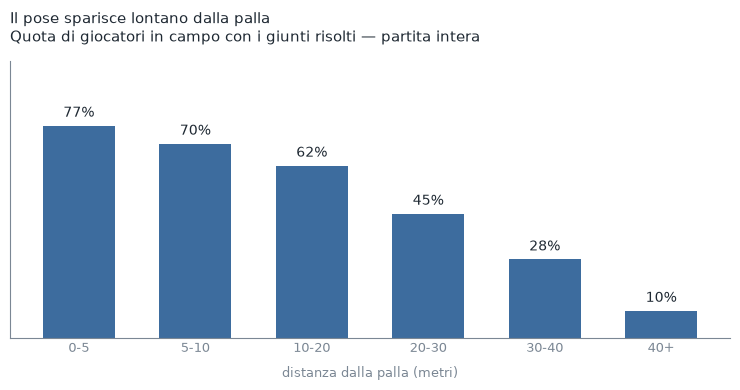

In [7]:
INK, MUTED, ACCENT = "#1f2933", "#7b8794", "#3d6c9e"

def spoglia(ax):
    for lato in ("top", "right"):
        ax.spines[lato].set_visible(False)
    for lato in ("left", "bottom"):
        ax.spines[lato].set_color(MUTED)
        ax.spines[lato].set_linewidth(0.8)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)


per_banda = pose.quote(cop["per_banda"])
chiavi = ["0-5", "5-10", "10-20", "20-30", "30-40", "40-999"]
valori = [per_banda[k] for k in chiavi]
etichette = chiavi[:-1] + ["40+"]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(etichette, valori, color=ACCENT, width=0.62)
for i, v in enumerate(valori):
    ax.text(i, v + 2, f"{v:.0f}%", ha="center", va="bottom", fontsize=10, color=INK)

ax.set_ylim(0, 100)
ax.set_yticks([])
ax.set_xlabel("distanza dalla palla (metri)", fontsize=9, color=MUTED, labelpad=8)
ax.set_title("Il pose sparisce lontano dalla palla\n"
             "Quota di giocatori in campo con i giunti risolti — partita intera",
             fontsize=11, color=INK, loc="left", pad=14)
spoglia(ax)
plt.tight_layout()
plt.show()

Stessa forma trovata per il tracking nell'esplorazione
[00](00-quanto-e-osservato.ipynb), spostata verso il basso: entro 5 metri dalla
palla il pose risolve il 77% dei giocatori, oltre i 40 metri il **10%**.

Il pose non introduce un limite nuovo: **eredita quello del rilevamento**. Su
questa partita il tracking rileva il 57,9% delle posizioni e il pose ne risolve
il 45,7% — il pose esiste dove e solo dove il giocatore è stato visto.

In [8]:
print("copertura del pose per ruolo (%):")
print(pose.quote(cop["per_ruolo"]).sort_values().round(1).to_string())

copertura del pose per ruolo (%):
GK     14.9
RCB    35.4
LCB    37.5
RB     44.3
LB     44.9
CF     50.4
RW     51.9
AM     52.2
LW     53.9
RDM    54.9
RM     59.5
LM     60.0
LDM    61.1


Il portiere al **15%**, lo stesso valore trovato nel tracking: è il giocatore più
spesso fuori inquadratura, e senza inquadratura non c'è posa. I centrali
difensivi stanno intorno al 36%, i centrocampisti sopra il 55%.

## Non tutti i giunti sono affidabili

Ogni giunto porta `p90_mae_cm`: il raggio entro cui cade il 90% delle stime. È il
campo che permette di scartare le pose inutilizzabili invece di fidarsi di tutte.

In [9]:
err = pose.errore_per_giunto(MATCH, limit=8000)
err.round(1)

neck          5.9
lShoulder     6.5
rShoulder     6.5
rEar          7.8
lEye          7.8
lEar          8.0
rEye          8.0
nose          8.1
rHip          8.4
lHip          8.6
lElbow        9.6
rElbow        9.7
midHip       10.2
rKnee        11.9
lKnee        11.9
lAnkle       15.4
lWrist       15.4
rAnkle       15.5
rWrist       15.9
lHeel        17.8
rHeel        18.0
rSmallToe    18.4
lSmallToe    18.4
lBigToe      18.5
lThumb       18.6
rBigToe      18.7
rThumb       19.1
lPinky       21.0
rPinky       21.2
dtype: float64

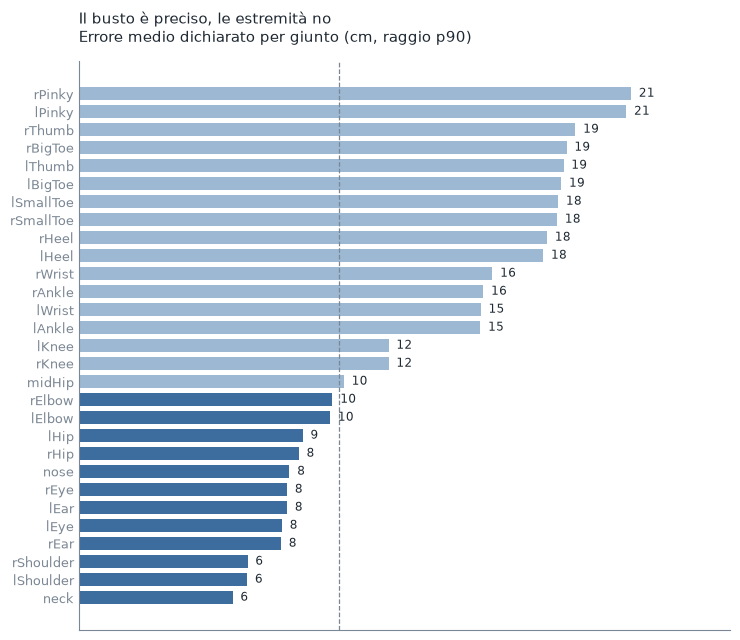

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
colori = [ACCENT if v <= 10 else "#9db8d2" for v in err.values]
ax.barh(err.index, err.values, color=colori, height=0.72)
for i, v in enumerate(err.values):
    ax.text(v + 0.3, i, f"{v:.0f}", va="center", fontsize=8.5, color=INK)

ax.axvline(10, color=MUTED, lw=0.9, ls="--")
ax.set_xlim(0, 25)
ax.set_xticks([])
ax.set_title("Il busto è preciso, le estremità no\n"
             "Errore medio dichiarato per giunto (cm, raggio p90)",
             fontsize=11, color=INK, loc="left", pad=14)
spoglia(ax)
plt.tight_layout()
plt.show()

Il gradiente è anatomico e consistente: collo e spalle intorno ai **6 cm**, anche
e gomiti sotto i 10, poi caviglie e polsi sopra i 15, e dita fino a **21 cm**.

La conseguenza è forte: **i giunti che servirebbero per capire cosa fa un
giocatore con i piedi sono i meno affidabili**, mentre quelli che sostengono una
misura di orientamento sono i migliori. Non è un caso che l'esempio ufficiale di
SkillCorner (`src/features/pose_orientation.py`) usi le spalle.

## Orientamento del busto

L'angolo è l'asse spalla sinistra → destra ruotato di +90°. Prima di usarlo vanno
applicati cinque filtri: ognuno, se ignorato, produce un numero plausibile e
sbagliato.

In [11]:
print(pose.copertura(pose.iter_match(MATCH, limit=8000)).to_string(index=False))

                       filtro      n quota
           player-frame visti 255200      
    senza pose (non rilevati) 161842 63.4%
             senza una spalla      0  0.0%
larghezza spalle implausibile    166  0.1%
               errore > 15 cm   2513  1.0%
                  **usabili**  90679 35.5%


Una verifica analitica prima di fidarsi del segno — sbagliarlo dà un angolo
ruotato di 180°, che è plausibile e completamente falso:

In [12]:
# Giocatore rivolto verso +x: spalla sinistra a +y, destra a -y.
prove = [((0, 0.2, 0, -0.2), 0), ((-0.2, 0, 0.2, 0), 90), ((0, -0.2, 0, 0.2), 180)]
for args, atteso in prove:
    print(f"atteso {atteso:4d}°   ottenuto {pose.orientamento_spalle_deg(*args):6.1f}°")

atteso    0°   ottenuto    0.0°
atteso   90°   ottenuto   90.0°
atteso  180°   ottenuto  180.0°


### Il controllo che conta: il busto segue la corsa?

Un modo onesto di validare la misura è confrontarla con qualcosa di noto. A
velocità alta un giocatore deve avere il busto allineato alla direzione di corsa:
non si sprinta di lato. Se il dato non lo mostra, la misura è sbagliata.

In [13]:
t = pose.orientamento_vs_moto(MATCH, limit=30000)
print(f"osservazioni con orientamento affidabile e v > 1 m/s: {len(t):,}")

osservazioni con orientamento affidabile e v > 1 m/s: 250,945


In [14]:
bande_v = pd.cut(t.v, [1, 2, 3, 5, 8, 20], labels=["1-2", "2-3", "3-5", "5-8", "8+"])
tab = t.groupby(bande_v, observed=True).scarto.agg(n="size", mediana="median")
tab["indietro_%"] = (t.groupby(bande_v, observed=True)
                      .scarto.apply(lambda s: 100 * (s > 90).mean()))
tab.round(1)

,n,mediana,indietro_%
v,,,
1-2,90236,21.4,16.2
2-3,61726,20.6,10.6
3-5,77629,16.3,4.3
5-8,21187,14.4,0.2
8+,167,13.3,0.0


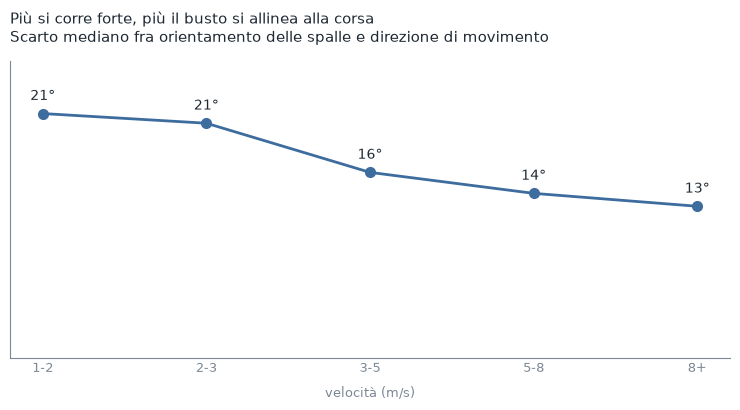

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(tab))
ax.plot(x, tab.mediana, color=ACCENT, lw=2, marker="o", ms=7)
for i, v in enumerate(tab.mediana):
    ax.text(i, v + 1.2, f"{v:.0f}°", ha="center", fontsize=10, color=INK)

ax.set_xticks(x)
ax.set_xticklabels(tab.index)
ax.set_ylim(0, 26)
ax.set_yticks([])
ax.set_xlabel("velocità (m/s)", fontsize=9, color=MUTED, labelpad=8)
ax.set_title("Più si corre forte, più il busto si allinea alla corsa\n"
             "Scarto mediano fra orientamento delle spalle e direzione di movimento",
             fontsize=11, color=INK, loc="left", pad=14)
spoglia(ax)
plt.tight_layout()
plt.show()

La misura si comporta come deve: lo scarto mediano cala al crescere della
velocità, e la quota di movimento "all'indietro" (scarto oltre 90°) crolla verso
lo zero.

È una validazione, non un risultato — ma senza non si può usare la misura. La
prima versione di questo calcolo dava una mediana di 160° e il 96% di corsa
all'indietro: il segno dell'angolo era invertito. Un numero implausibile è
l'unico modo in cui quel bug si manifesta.

**E il residuo è il segnale interessante.** La quota di movimento all'indietro a
bassa velocità non è rumore: è gente che si muove senza guardare dove va —
difensori che accompagnano indietro tenendo d'occhio la palla, cioè esattamente
la situazione in cui l'orientamento dice qualcosa che la posizione da sola non
dice.

## Cosa regge e cosa no

| | |
|---|---|
| Partite con pose | **2 su 20** |
| Frequenza | 25 fps (il tracking è a 10) |
| Copertura, giocatori in campo | **45,7%** |
| entro 5 m dalla palla | 77% |
| oltre 40 m dalla palla | **10%** |
| portiere | 15% |
| Giunti affidabili | busto — collo, spalle, anche: 6-9 cm |
| Giunti inaffidabili | mani e piedi: 15-21 cm |
| `z` | relativa al centroide, **non** altezza dal campo |

**Regge**: misure di orientamento del busto per giocatori vicini alla palla, in
gioco attivo. Cioè duelli, ingaggi, pressione sul portatore.

**Non regge**: qualunque cosa richieda i piedi, l'altezza dal suolo, i giocatori
lontani dall'azione, o una popolazione statistica — con due partite non si
descrive un campionato.

### Cosa apre

Le `on_ball_engagement` sono **1.961 nelle due partite con pose**, su 17.445
totali. Sono eventi ravvicinati per definizione, quindi cadono proprio dove il
pose funziona meglio.

Questo suggerisce un lavoro a due livelli, annotato in
[`plans/01`](../plans/01-scegliere-la-domanda.md): il modello della scelta
difensiva sulle 20 partite, dove il campione c'è; l'arricchimento con
l'orientamento sulle 2 con pose, dichiarato come dimostrazione di metodo e non
come risultato di popolazione.

### Rimasto fuori

- La seconda partita con pose (`1996435`) non è stata scaricata: tutti i numeri
  qui vengono da `1925299` e vanno confermati sull'altra.
- Gli altri 27 giunti oltre le spalle. Anche e ginocchia hanno errori bassi e
  potrebbero sostenere misure di postura più fini.
- L'orientamento **relativo** — busto rispetto alla palla, o rispetto alla porta
  — che è la forma in cui la misura diventa tatticamente leggibile.